# Team 5 항공 승객 만족도 예측 및 승객 군집 분석

## 1. 프로젝트 소개와 문제 정의

- **타깃:** `satisfaction`
- **문제 유형:** 이진분류
- **0:** `neutral or dissatisfied`
- **1:** `satisfied`
- **비즈니스 목적:** 불만족 가능성이 높은 승객을 식별하고 만족도에 영향을 주는 서비스 요인과 승객 유형을 파악하여 개선 우선순위를 제안한다.
- **데이터 출처:** [Kaggle Airline Passenger Satisfaction](https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction)
- **라이선스:** Kaggle 데이터 페이지에 표시된 `Other (specified in description)` 조건을 따른다. Kaggle 공개 페이지에서 표시 문구를 재확인했으며 접근일은 2026-08-23이다. 세부 이용 조건은 데이터 설명의 원문을 따라야 하며, 공개 화면만으로 별도 표준 라이선스명을 확정하지 않는다.
- **핵심 지표:** Accuracy, F1-score
- **프로젝트 성공 기준:** DummyClassifier와 Logistic Regression 기준선을 상회하고, Stratified 5-Fold에서 평균 F1이 안정적으로 유지되며, train-validation 성능 격차가 과도하지 않은 모델을 성공적인 모델로 판단한다. Accuracy와 F1-score를 함께 확인하며 단일 최고 점수만으로 최종 모델을 선택하지 않는다.
- **보조 지표:** Precision, Recall, ROC-AUC, Confusion Matrix

공식 기본 결과는 임계값 **0.50**으로 평가한다. 임계값 0.75는 FP 감소가 특히 중요한 운영 환경을 가정한 별도 시나리오로만 제시한다. 공식 `test.csv`는 최종 모델과 임계값을 확정한 후 한 번만 평가한다.

## 2. 실행 환경과 데이터 로딩

In [1]:
import sys, time, warnings, platform
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn, xgboost, lightgbm, shap
from IPython.display import display, Markdown
from sklearn import set_config

warnings.filterwarnings("ignore", category=FutureWarning)
set_config(display="text")
RANDOM_STATE = 10
pd.set_option("display.max_columns", 100)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font="Malgun Gothic")

versions = pd.DataFrame({
    "항목": ["Python", "pandas", "numpy", "scikit-learn", "xgboost", "lightgbm", "shap", "matplotlib", "seaborn"],
    "버전": [sys.version.split()[0], pd.__version__, np.__version__, sklearn.__version__, xgboost.__version__, lightgbm.__version__, shap.__version__, plt.matplotlib.__version__, sns.__version__]
})
display(versions.style.hide(axis="index"))

항목,버전
Python,3.14.6
pandas,3.0.3
numpy,2.5.1
scikit-learn,1.9.0
xgboost,3.4.0
lightgbm,4.7.0
shap,0.52.0
matplotlib,3.11.1
seaborn,0.13.2


In [2]:
DATA_DIR = Path(r"C:\Users\KDS-18\Desktop\team5_pro\data")
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
assert TRAIN_PATH.exists() and TEST_PATH.exists(), "데이터 경로를 확인하세요."

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
print("train 원본:", train.shape)
print("test 원본:", test.shape)
print("train/test 컬럼 일치:", train.columns.equals(test.columns))

train 원본: (103904, 25)
test 원본: (25976, 25)
train/test 컬럼 일치: True


### 원본 데이터 구조 확인

모델링 전에 원본 데이터의 실제 행 형태, 컬럼명, 자료형과 요약통계를 확인한다. 이 단계에서는 값을 변환하지 않으며, 식별자 제거·결측치 처리·인코딩 여부를 결정하기 위한 기초 점검만 수행한다.

In [3]:
display(train.head())

print("[train.info()]")
train.info()

print("\n[test.info()]")
test.info()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.0,satisfied


[train.info()]
<class 'pandas.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  str    
 3   Customer Type                      103904 non-null  str    
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  str    
 6   Class                              103904 non-null  str    
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      

In [4]:
numeric_summary = train.select_dtypes(include="number").describe().T
categorical_summary = pd.DataFrame({
    "자료형": train.select_dtypes(exclude="number").dtypes.astype(str),
    "고유값 수": train.select_dtypes(exclude="number").nunique(dropna=False),
    "최빈값": train.select_dtypes(exclude="number").mode(dropna=False).iloc[0]
})

display(numeric_summary.round(2))
display(categorical_summary)
display(Markdown(
    "**초기 확인:** 원본에는 식별자 역할의 `Unnamed: 0`, `id`가 있으며 모델 입력에서는 제거한다. "
    "범주형 변수는 문자열이고, 도착 지연시간에만 일부 결측치가 있어 이후 Pipeline 내부 중앙값 대체 대상으로 정한다."
))

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,103904.0,51951.50,29994.65,0.0,25975.75,51951.5,77927.25,103903.0
id,103904.0,64924.21,37463.81,1.0,32533.75,64856.5,97368.25,129880.0
Age,103904.0,39.38,15.11,7.0,27.00,40.0,51.00,85.0
Flight Distance,103904.0,1189.45,997.15,31.0,414.00,843.0,1743.00,4983.0
Inflight wifi service,103904.0,2.73,1.33,0.0,2.00,3.0,4.00,5.0
Departure/Arrival time convenient,103904.0,3.06,1.53,0.0,2.00,3.0,4.00,5.0
Ease of Online booking,103904.0,2.76,1.40,0.0,2.00,3.0,4.00,5.0
Gate location,103904.0,2.98,1.28,0.0,2.00,3.0,4.00,5.0
Food and drink,103904.0,3.20,1.33,0.0,2.00,3.0,4.00,5.0
Online boarding,103904.0,3.25,1.35,0.0,2.00,3.0,4.00,5.0


,자료형,고유값 수,최빈값
Gender,str,2,Female
Customer Type,str,2,Loyal Customer
Type of Travel,str,2,Business travel
Class,str,3,Business
satisfaction,str,2,neutral or dissatisfied


**초기 확인:** 원본에는 식별자 역할의 `Unnamed: 0`, `id`가 있으며 모델 입력에서는 제거한다. 범주형 변수는 문자열이고, 도착 지연시간에만 일부 결측치가 있어 이후 Pipeline 내부 중앙값 대체 대상으로 정한다.

### 주요 수치형 변수의 원본 분포

나이·비행거리·지연시간의 분포를 먼저 확인해 중앙값 대체, 이상치 유지 및 스케일링 여부의 근거로 사용한다. 지연시간 그래프는 긴 꼬리 때문에 중심 구간이 보이지 않는 문제를 줄이려고 **시각화에서만** 상위 1%를 제외한다. 실제 학습 행은 삭제하지 않는다.

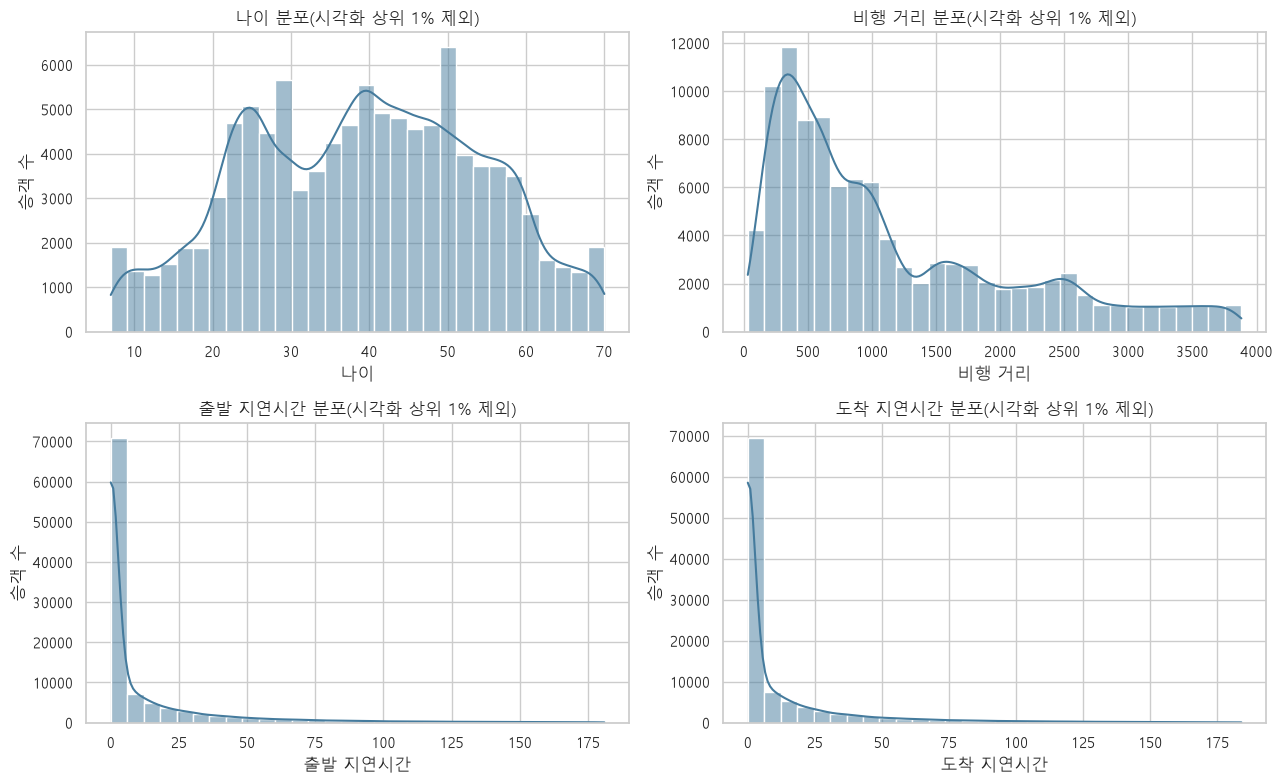

**해석:** 비행거리와 지연시간은 오른쪽으로 치우쳐 있고 지연시간에는 큰 값이 존재한다. 이는 실제 운항 지연일 수 있으므로 학습 데이터에서는 삭제하지 않는다. 도착 지연 결측치는 중앙값으로 대체하고, 단위 차이에 민감한 로지스틱 회귀에만 표준화를 적용한다.

In [5]:
distribution_cols = [
    "Age", "Flight Distance",
    "Departure Delay in Minutes", "Arrival Delay in Minutes"
]
distribution_korean = {
    "Age": "나이",
    "Flight Distance": "비행 거리",
    "Departure Delay in Minutes": "출발 지연시간",
    "Arrival Delay in Minutes": "도착 지연시간"
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.flat, distribution_cols):
    values = train[col].dropna()
    visual_upper = values.quantile(0.99)
    sns.histplot(
        values[values <= visual_upper], bins=30, kde=True,
        color="#457B9D", ax=ax
    )
    ax.set(
        title=f"{distribution_korean[col]} 분포(시각화 상위 1% 제외)",
        xlabel=distribution_korean[col], ylabel="승객 수"
    )
plt.tight_layout(); plt.show()

display(Markdown(
    "**해석:** 비행거리와 지연시간은 오른쪽으로 치우쳐 있고 지연시간에는 큰 값이 존재한다. "
    "이는 실제 운항 지연일 수 있으므로 학습 데이터에서는 삭제하지 않는다. 도착 지연 결측치는 중앙값으로 대체하고, "
    "단위 차이에 민감한 로지스틱 회귀에만 표준화를 적용한다."
))

### 서비스 변수 상관관계 히트맵

서비스 평가끼리 비슷한 응답 패턴을 보이는지 확인한다. 높은 상관관계는 정보 중복과 다중공선성 가능성을 뜻하지만, 곧바로 변수를 삭제해야 한다는 의미는 아니다.

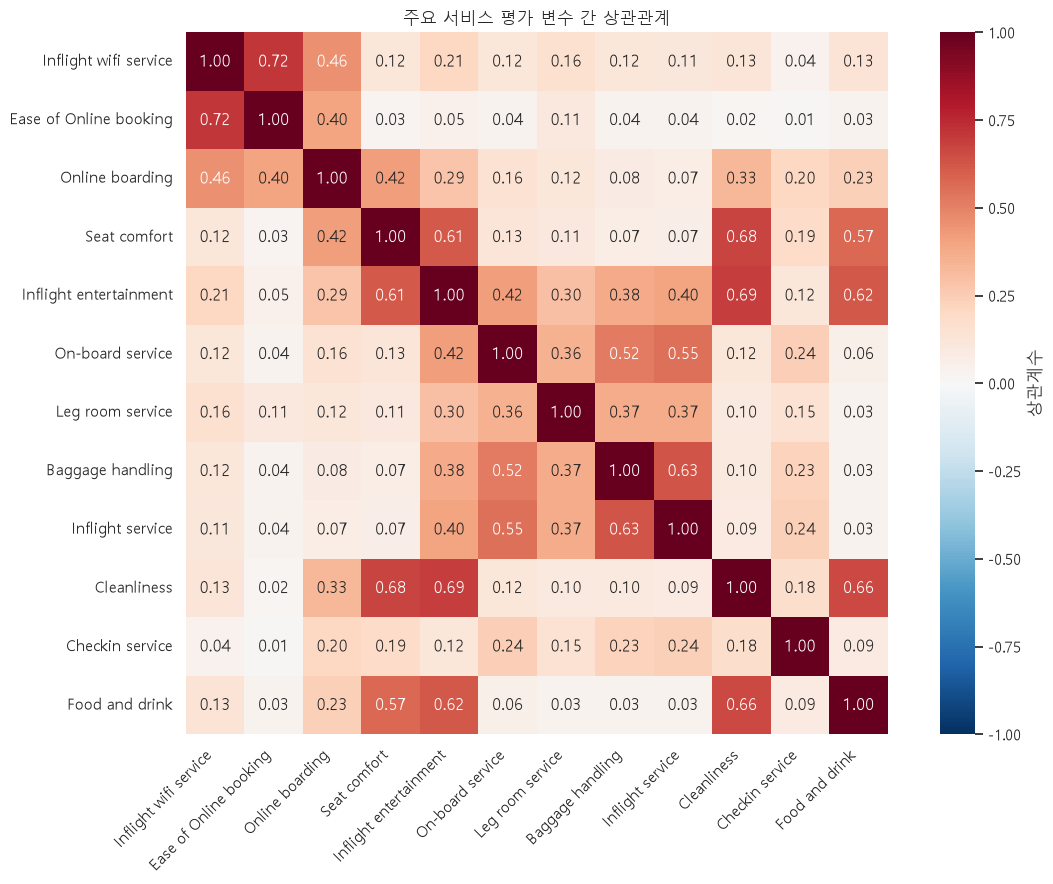

**해석:** 일부 객실·기내 서비스 평가는 서로 높은 양의 상관관계를 보인다. 로지스틱 회귀 계수나 개별 Feature Importance를 해석할 때 관련 변수들이 중요도를 나누어 가질 수 있음을 고려한다. 트리 모델 비교에서는 변수를 일괄 삭제하지 않고 교차검증 성능과 SHAP을 함께 확인한다.

In [6]:
service_for_heatmap = [
    "Inflight wifi service", "Ease of Online booking", "Online boarding",
    "Seat comfort", "Inflight entertainment", "On-board service",
    "Leg room service", "Baggage handling", "Inflight service",
    "Cleanliness", "Checkin service", "Food and drink"
]
service_corr = train[service_for_heatmap].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    service_corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", square=True,
    cbar_kws={"label": "상관계수"}
)
plt.title("주요 서비스 평가 변수 간 상관관계")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

display(Markdown(
    "**해석:** 일부 객실·기내 서비스 평가는 서로 높은 양의 상관관계를 보인다. "
    "로지스틱 회귀 계수나 개별 Feature Importance를 해석할 때 관련 변수들이 중요도를 나누어 가질 수 있음을 고려한다. "
    "트리 모델 비교에서는 변수를 일괄 삭제하지 않고 교차검증 성능과 SHAP을 함께 확인한다."
))

In [7]:
basic_check = pd.DataFrame({
    "구분": ["train", "test"],
    "행": [len(train), len(test)],
    "열": [train.shape[1], test.shape[1]],
    "중복 행": [train.duplicated().sum(), test.duplicated().sum()],
    "전체 결측치": [train.isna().sum().sum(), test.isna().sum().sum()]
})
display(basic_check.style.hide(axis="index"))

missing_df = pd.DataFrame({
    "train 결측 수": train.isna().sum(),
    "train 결측률(%)": train.isna().mean() * 100,
    "test 결측 수": test.isna().sum(),
    "test 결측률(%)": test.isna().mean() * 100
}).query("`train 결측 수` > 0 or `test 결측 수` > 0")
display(missing_df.round(4))

구분,행,열,중복 행,전체 결측치
train,103904,25,0,310
test,25976,25,0,83


,train 결측 수,train 결측률(%),test 결측 수,test 결측률(%)
Arrival Delay in Minutes,310,0.2984,83,0.3195


In [8]:
ID_COLS = ["Unnamed: 0", "id"]
TARGET = "satisfaction"
train = train.drop(columns=ID_COLS)
test = test.drop(columns=ID_COLS)
assert train.columns.equals(test.columns)
assert TARGET in train.columns
print("식별자 제거 후:", train.shape, test.shape)

식별자 제거 후: (103904, 23) (25976, 23)


## 3. 핵심 EDA

발표에 필요한 다섯 가지 관계만 확인한다. EDA는 전체 공식 train에서 수행하지만, 전처리 통계의 `fit`에는 사용하지 않는다.

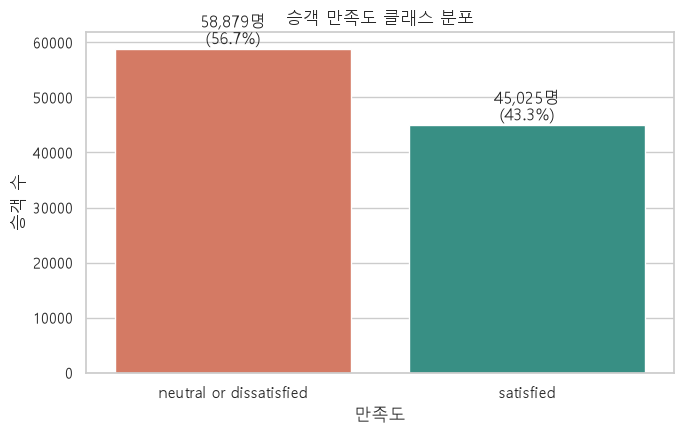

**해석:** 불만족·중립 56.7%, 만족 43.3%로 심각한 불균형은 아니다. 따라서 재표본화 없이 Accuracy와 F1을 함께 평가한다.

In [9]:
target_order = ["neutral or dissatisfied", "satisfied"]
target_counts = train[TARGET].value_counts().reindex(target_order)
target_ratio = train[TARGET].value_counts(normalize=True).reindex(target_order) * 100

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(x=target_counts.index, y=target_counts.values, palette=["#E76F51", "#2A9D8F"], ax=ax)
for i, (count, ratio) in enumerate(zip(target_counts, target_ratio)):
    ax.text(i, count + 800, f"{count:,}명\n({ratio:.1f}%)", ha="center")
ax.set(title="승객 만족도 클래스 분포", xlabel="만족도", ylabel="승객 수")
plt.tight_layout(); plt.show()
display(Markdown(f"**해석:** 불만족·중립 {target_ratio.iloc[0]:.1f}%, 만족 {target_ratio.iloc[1]:.1f}%로 심각한 불균형은 아니다. 따라서 재표본화 없이 Accuracy와 F1을 함께 평가한다."))

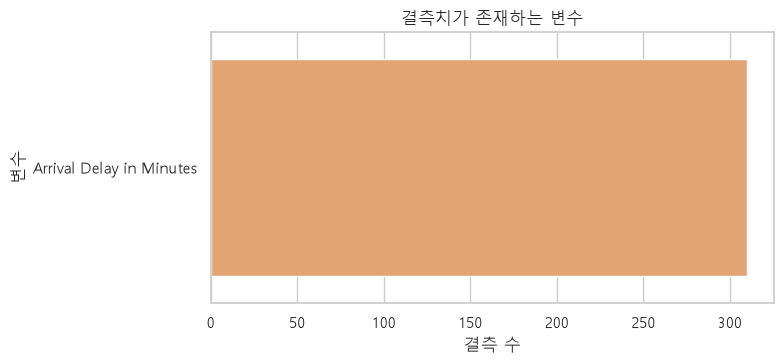

**해석:** 도착 지연시간의 결측률은 0.298%로 낮다. 변수를 삭제하지 않고, 데이터 누수를 막기 위해 Pipeline 안에서 fold별 학습 중앙값으로 대체한다.

In [10]:
missing_plot = train.isna().sum().sort_values(ascending=False)
missing_plot = missing_plot[missing_plot > 0]
fig, ax = plt.subplots(figsize=(8, 3.8))
sns.barplot(x=missing_plot.values, y=missing_plot.index, color="#F4A261", ax=ax)
ax.set(title="결측치가 존재하는 변수", xlabel="결측 수", ylabel="변수")
plt.tight_layout(); plt.show()
arrival_rate = train["Arrival Delay in Minutes"].isna().mean() * 100
display(Markdown(f"**해석:** 도착 지연시간의 결측률은 {arrival_rate:.3f}%로 낮다. 변수를 삭제하지 않고, 데이터 누수를 막기 위해 Pipeline 안에서 fold별 학습 중앙값으로 대체한다."))

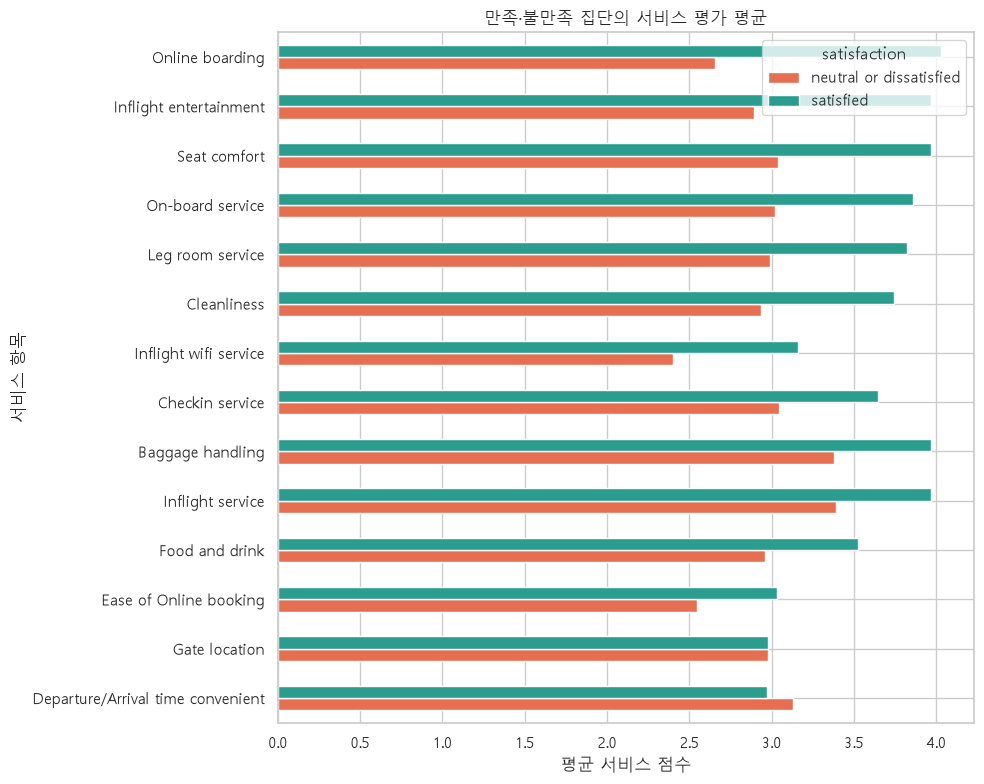

**해석:** 집단 간 평균 차이가 큰 상위 항목은 Online boarding, Inflight entertainment, Seat comfort이다. 이는 관련성이며 인과관계를 의미하지 않는다.

In [11]:
service_cols = [
    "Inflight wifi service", "Departure/Arrival time convenient", "Ease of Online booking",
    "Gate location", "Food and drink", "Online boarding", "Seat comfort",
    "Inflight entertainment", "On-board service", "Leg room service",
    "Baggage handling", "Checkin service", "Inflight service", "Cleanliness"
]
service_mean = train.groupby(TARGET)[service_cols].mean().T
service_mean["평균 차이"] = service_mean["satisfied"] - service_mean["neutral or dissatisfied"]
service_mean = service_mean.sort_values("평균 차이")
service_mean[["neutral or dissatisfied", "satisfied"]].plot(kind="barh", figsize=(10, 8), color=["#E76F51", "#2A9D8F"])
plt.title("만족·불만족 집단의 서비스 평가 평균")
plt.xlabel("평균 서비스 점수"); plt.ylabel("서비스 항목"); plt.tight_layout(); plt.show()
top_gap = service_mean["평균 차이"].abs().sort_values(ascending=False).head(3).index.tolist()
display(Markdown("**해석:** 집단 간 평균 차이가 큰 상위 항목은 " + ", ".join(top_gap) + "이다. 이는 관련성이며 인과관계를 의미하지 않는다."))

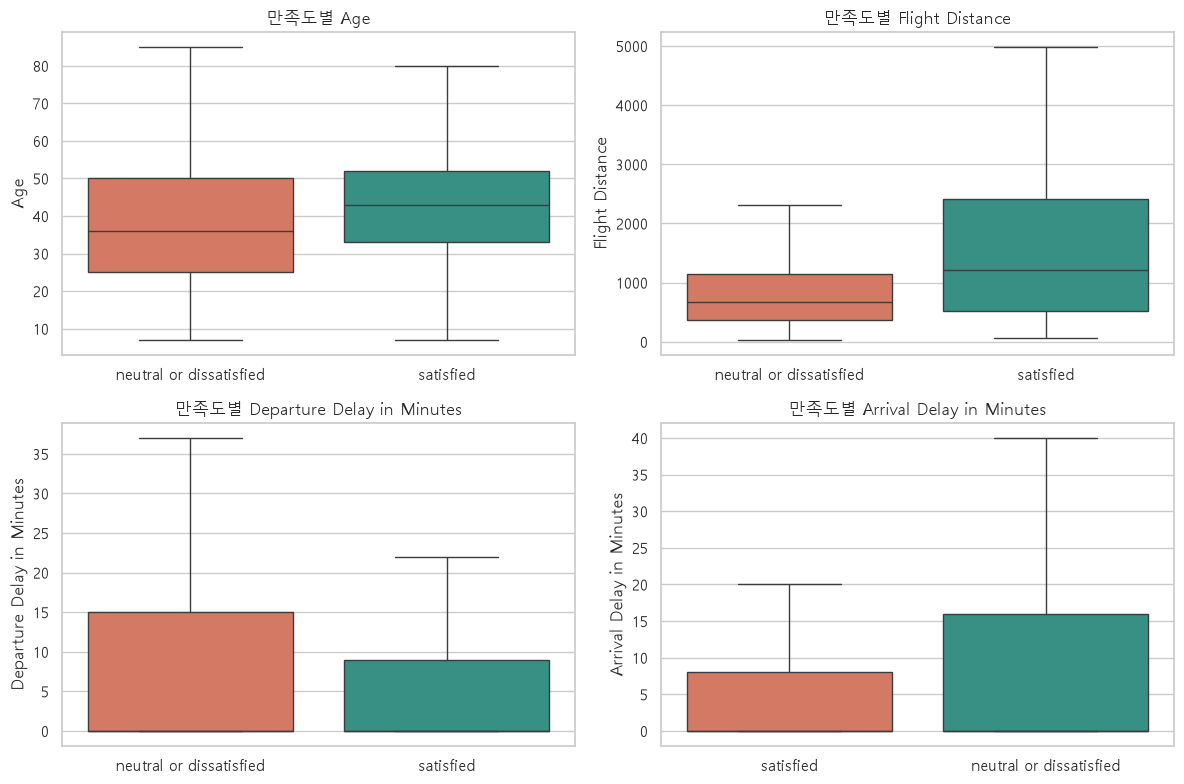

**해석:** 지연시간은 오른쪽 꼬리가 길지만 실제 운항 상황일 수 있어 삭제하지 않는다. 출발·도착 지연의 상관계수는 0.9655로 높으므로 중요도 해석에서 중복 정보를 고려한다.

In [12]:
eda_num = train.copy()
eda_num["만족 여부"] = eda_num[TARGET].map({"neutral or dissatisfied": 0, "satisfied": 1})
numeric_relation = ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, numeric_relation):
    sample = eda_num[[col, TARGET]].dropna().sample(n=min(30000, eda_num[col].notna().sum()), random_state=RANDOM_STATE)
    sns.boxplot(data=sample, x=TARGET, y=col, showfliers=False, palette=["#E76F51", "#2A9D8F"], ax=ax)
    ax.set_title(f"만족도별 {col}"); ax.set_xlabel("")
plt.tight_layout(); plt.show()
delay_corr = train[["Departure Delay in Minutes", "Arrival Delay in Minutes"]].corr().iloc[0,1]
display(Markdown(f"**해석:** 지연시간은 오른쪽 꼬리가 길지만 실제 운항 상황일 수 있어 삭제하지 않는다. 출발·도착 지연의 상관계수는 {delay_corr:.4f}로 높으므로 중요도 해석에서 중복 정보를 고려한다."))

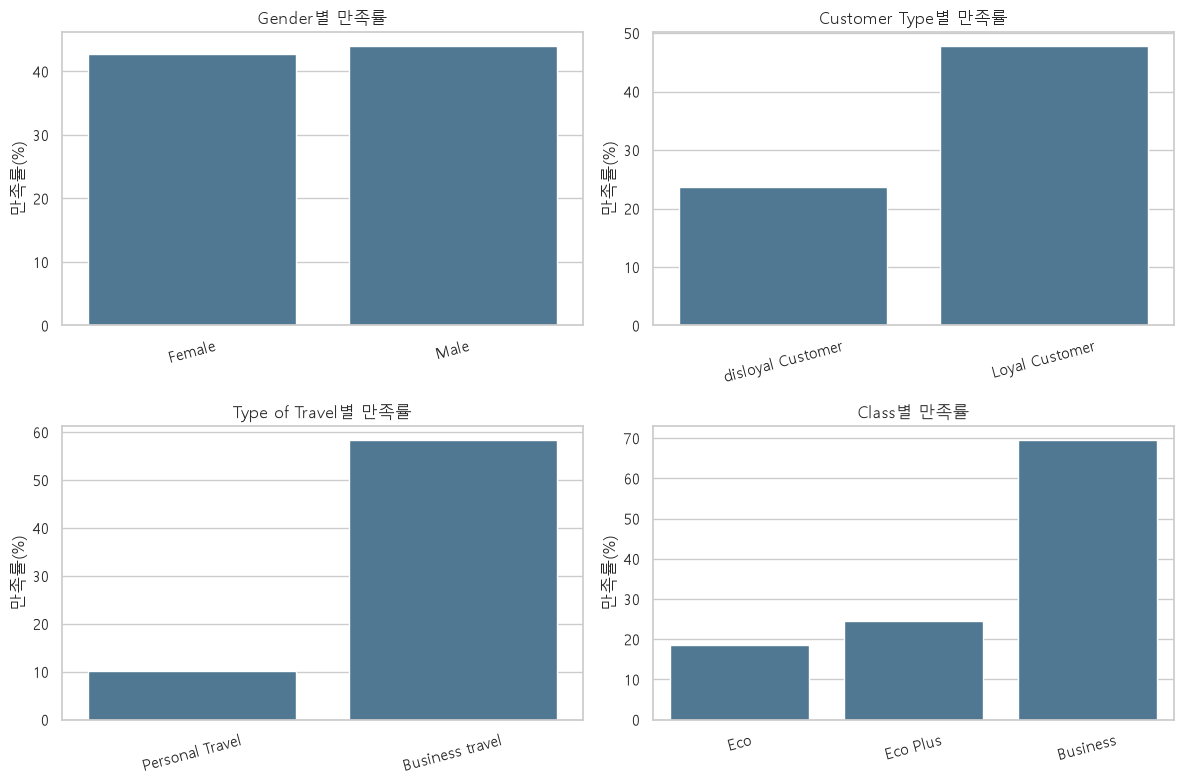

**해석:** 여행 목적·좌석 등급·고객 유형에 따라 만족률 차이가 나타난다. 이들은 명목형 변수이므로 임의 순서를 부여하지 않고 One-Hot Encoding을 적용한다.

In [13]:
categorical_cols_eda = ["Gender", "Customer Type", "Type of Travel", "Class"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, categorical_cols_eda):
    rate = train.assign(만족여부=train[TARGET].eq("satisfied")).groupby(col)["만족여부"].mean().mul(100).sort_values()
    sns.barplot(x=rate.index, y=rate.values, color="#457B9D", ax=ax)
    ax.set(title=f"{col}별 만족률", xlabel="", ylabel="만족률(%)")
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()
display(Markdown("**해석:** 여행 목적·좌석 등급·고객 유형에 따라 만족률 차이가 나타난다. 이들은 명목형 변수이므로 임의 순서를 부여하지 않고 One-Hot Encoding을 적용한다."))

### 범주형 카디널리티와 결측 패턴 보완

범주형 변수의 고유값 수를 확인해 One-Hot Encoding의 크기가 과도하지 않은지 검토한다. 또한 `Arrival Delay in Minutes`의 결측 여부별 만족률을 비교해 결측이 특정 타깃에 집중되는지 확인한다. 이 비교는 결측값 자체로 타깃을 대체하거나 test 정보를 사용하는 과정이 아니다.

In [14]:
categorical_cardinality = pd.DataFrame({
    "범주형 변수": categorical_cols_eda,
    "고유값 수": [train[col].nunique(dropna=False) for col in categorical_cols_eda],
    "고유값": [", ".join(map(str, train[col].drop_duplicates().tolist())) for col in categorical_cols_eda]
})
display(categorical_cardinality.style.hide(axis="index"))

arrival_missing_pattern = (
    train.assign(
        도착지연_결측=train["Arrival Delay in Minutes"].isna(),
        만족여부=train[TARGET].eq("satisfied")
    )
    .groupby("도착지연_결측")
    .agg(승객_수=(TARGET, "size"), 만족률=("만족여부", "mean"))
    .reset_index()
)
arrival_missing_pattern["만족률(%)"] = arrival_missing_pattern.pop("만족률") * 100
display(arrival_missing_pattern.round(3).style.hide(axis="index"))

missing_gap = arrival_missing_pattern["만족률(%)"].max() - arrival_missing_pattern["만족률(%)"].min()
display(Markdown(
    f"**해석:** 범주형 변수의 고유값 수가 작아 One-Hot Encoding이 적절하다. "
    f"도착 지연 결측 여부별 만족률 차이는 {missing_gap:.2f}%p이며, 결측률 자체가 0.3% 수준이므로 "
    "행 삭제보다 Pipeline 내부 중앙값 대체를 유지한다."
))

범주형 변수,고유값 수,고유값
Gender,2,"Male, Female"
Customer Type,2,"Loyal Customer, disloyal Customer"
Type of Travel,2,"Personal Travel, Business travel"
Class,3,"Eco Plus, Business, Eco"


도착지연_결측,승객_수,만족률(%)
False,103594,43.339000
True,310,41.290000


**해석:** 범주형 변수의 고유값 수가 작아 One-Hot Encoding이 적절하다. 도착 지연 결측 여부별 만족률 차이는 2.05%p이며, 결측률 자체가 0.3% 수준이므로 행 삭제보다 Pipeline 내부 중앙값 대체를 유지한다.

### 서비스 점수 범위와 피처 간 상관관계 보완

서비스 점수의 0을 임의로 결측 처리하지 않기 위해 실제 범위와 0의 빈도를 확인한다. 또한 전체 수치형 피처 중 상관계수가 큰 쌍을 표로 확인해, 같은 현상을 측정하는 변수가 중요도를 나누어 가질 가능성을 점검한다.

In [15]:
service_scale_check = pd.DataFrame({
    "서비스 변수": service_cols,
    "최솟값": [train[col].min() for col in service_cols],
    "최댓값": [train[col].max() for col in service_cols],
    "0값 수": [(train[col] == 0).sum() for col in service_cols],
    "결측 수": [train[col].isna().sum() for col in service_cols]
})
display(service_scale_check.style.hide(axis="index"))

numeric_corr = train.select_dtypes(include="number").corr()
upper_mask = np.triu(np.ones(numeric_corr.shape, dtype=bool), k=1)
top_corr_pairs = (
    numeric_corr.where(upper_mask)
    .stack()
    .rename("상관계수")
    .reset_index()
    .rename(columns={"level_0": "변수 1", "level_1": "변수 2"})
)
top_corr_pairs["절댓값"] = top_corr_pairs["상관계수"].abs()
top_corr_pairs = top_corr_pairs.sort_values("절댓값", ascending=False).head(10)
display(top_corr_pairs.drop(columns="절댓값").round(4).style.hide(axis="index"))

display(Markdown(
    "**해석:** 서비스 변수는 0~5 범위이고 결측치는 없다. 0의 구체적인 설문 의미는 데이터 설명만으로 확정하기 어려우므로 "
    "결측치로 재분류하지 않고 원자료 값으로 유지한다. 높은 상관관계를 가진 변수는 같은 정보를 일부 공유할 수 있으므로 "
    "Feature Importance를 개별 변수의 독립적 인과효과로 해석하지 않는다."
))

서비스 변수,최솟값,최댓값,0값 수,결측 수
Inflight wifi service,0,5,3103,0
Departure/Arrival time convenient,0,5,5300,0
Ease of Online booking,0,5,4487,0
Gate location,0,5,1,0
Food and drink,0,5,107,0
Online boarding,0,5,2428,0
Seat comfort,0,5,1,0
Inflight entertainment,0,5,14,0
On-board service,0,5,3,0
Leg room service,0,5,472,0


변수 1,변수 2,상관계수
Departure Delay in Minutes,Arrival Delay in Minutes,0.965500
Inflight wifi service,Ease of Online booking,0.715900
Inflight entertainment,Cleanliness,0.691800
Seat comfort,Cleanliness,0.678500
Food and drink,Cleanliness,0.657800
Baggage handling,Inflight service,0.628600
Food and drink,Inflight entertainment,0.622500
Seat comfort,Inflight entertainment,0.610600
Food and drink,Seat comfort,0.574600
On-board service,Inflight service,0.550800


**해석:** 서비스 변수는 0~5 범위이고 결측치는 없다. 0의 구체적인 설문 의미는 데이터 설명만으로 확정하기 어려우므로 결측치로 재분류하지 않고 원자료 값으로 유지한다. 높은 상관관계를 가진 변수는 같은 정보를 일부 공유할 수 있으므로 Feature Importance를 개별 변수의 독립적 인과효과로 해석하지 않는다.

### EDA에서 전처리로 연결한 결정

- 도착 지연시간 결측률이 낮으므로 삭제하지 않고 중앙값 대체한다.
- 지연시간의 긴 꼬리는 오류로 단정할 수 없어 분류 입력의 원본 값을 유지한다.
- 0~5의 서비스 점수는 설문 척도이므로 이상치로 삭제하지 않는다.
- 로지스틱 회귀에는 수치형 표준화를 적용하고, 트리 계열에는 중앙값 대체만 적용한다.
- 범주형 변수는 순서가 없으므로 One-Hot Encoding을 사용한다.

## 4. 데이터 분할과 test 보호

In [16]:
target_map = {"neutral or dissatisfied": 0, "satisfied": 1}
X = train.drop(columns=TARGET).copy()
y = train[TARGET].map(target_map)
X_test = test.drop(columns=TARGET).copy()
y_test = test[TARGET].map(target_map)

from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print("train:", X_train.shape, "validation:", X_valid.shape, "공식 test(보호):", X_test.shape)
assert TARGET not in X.columns
assert X.columns.equals(X_test.columns)
assert set(ID_COLS).isdisjoint(X.columns)

train: (83123, 22) validation: (20781, 22) 공식 test(보호): (25976, 22)


## 5. 누수 방지 전처리 Pipeline

- `SimpleImputer`는 수업의 `fillna(중앙값)`를 각 CV fold의 학습 부분 안에서 재현한다.
- `ColumnTransformer`는 수치형과 범주형에 서로 다른 전처리를 적용한다.
- `Pipeline`은 전처리와 모델을 묶어 validation/test 정보가 전처리 `fit`에 들어가는 것을 막는다.
- `StratifiedKFold`는 각 fold에서 만족·불만족 비율을 유지한다.

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_cols = X_train.select_dtypes(exclude="number").columns.tolist()
numeric_cols = X_train.select_dtypes(include="number").columns.tolist()

logistic_preprocessor = ColumnTransformer([
    ("numeric", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_cols),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])
tree_preprocessor = ColumnTransformer([
    ("numeric", SimpleImputer(strategy="median"), numeric_cols),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])
print("수치형:", len(numeric_cols), "범주형:", categorical_cols)

수치형: 18 범주형: ['Gender', 'Customer Type', 'Type of Travel', 'Class']


## 6. 베이스라인과 5개 모델의 동일 교차검증 비교

In [18]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
models = {
    "Dummy": Pipeline([("preprocessor", tree_preprocessor), ("model", DummyClassifier(strategy="most_frequent"))]),
    "Logistic Regression": Pipeline([("preprocessor", logistic_preprocessor), ("model", LogisticRegression(max_iter=1000, solver="liblinear", random_state=RANDOM_STATE))]),
    "Decision Tree": Pipeline([("preprocessor", tree_preprocessor), ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))]),
    "Random Forest": Pipeline([("preprocessor", tree_preprocessor), ("model", RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE, n_jobs=1))]),
    "XGBoost": Pipeline([("preprocessor", tree_preprocessor), ("model", XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=1))]),
    "LightGBM": Pipeline([("preprocessor", tree_preprocessor), ("model", LGBMClassifier(n_estimators=200, learning_rate=0.05, random_state=RANDOM_STATE, n_jobs=1, verbosity=-1))])
}

In [19]:
base_rows=[]
base_fitted={}
base_cv_scores = {}

for name, model in models.items():
    started=time.perf_counter()
    scores_cv=cross_validate(model, X_train, y_train, scoring="f1", cv=cv, n_jobs=-1, return_train_score=True)
    base_cv_scores[name] = (scores_cv["test_score"])
    model.fit(X_train, y_train)
    pred_train=model.predict(X_train); pred_valid=model.predict(X_valid)
    elapsed=time.perf_counter()-started
    row={
        "실험": len(base_rows)+1, "모델": name, "파라미터": "기본 설정",
        "CV 평균 F1": scores_cv["test_score"].mean(), "CV 표준편차": scores_cv["test_score"].std(),
        "검증 Accuracy": accuracy_score(y_valid,pred_valid), "검증 F1": f1_score(y_valid,pred_valid),
        "학습 F1": f1_score(y_train,pred_train), "과적합 격차": f1_score(y_train,pred_train)-f1_score(y_valid,pred_valid),
        "실행 시간(초)": elapsed
    }
    base_rows.append(row); base_fitted[name]=model
base_results=pd.DataFrame(base_rows).sort_values("CV 평균 F1",ascending=False)
display(base_results.round(4).style.hide(axis="index"))
lgbm_rf_fold_comparison = pd.DataFrame({
    "Fold": range(1, 6),
    "LightGBM F1": (
        base_cv_scores["LightGBM"]
    ),
    "Random Forest F1": (
        base_cv_scores[
            "Random Forest"
        ]
    )
})

lgbm_rf_fold_comparison["F1 차이"] = (
    lgbm_rf_fold_comparison[
        "LightGBM F1"
    ]
    - lgbm_rf_fold_comparison[
        "Random Forest F1"
    ]
)

display(
    lgbm_rf_fold_comparison
    .round(4)
    .style
    .hide(axis="index")
)

mean_difference = (
    lgbm_rf_fold_comparison[
        "F1 차이"
    ].mean()
)

display(
    Markdown(
        f"""
**해석:** LightGBM과 Random Forest의
교차검증 평균 F1 차이는 약
{mean_difference:.4f}이다.

두 모델의 성능 차이가 크지 않으므로
LightGBM이 압도적으로 우수하다고
판단하지 않았다. Random Forest는
학습 F1이 1.0000이고 과적합 격차가
큰 반면 LightGBM은 유사한 검증
성능에서 일반화 격차가 작았다.
"""
    )
)

lgbm_cv = base_results.loc[base_results["모델"] == "LightGBM", "CV 평균 F1"].iloc[0]
rf_cv = base_results.loc[base_results["모델"] == "Random Forest", "CV 평균 F1"].iloc[0]
display(Markdown(
    f"**모델 차이 해석:** LightGBM과 Random Forest의 CV 평균 F1 차이는 {lgbm_cv-rf_cv:.4f}로 작다. "
    "따라서 LightGBM을 압도적으로 우수하다고 표현하지 않고, train-validation 격차와 실행 시간까지 함께 고려한다."
))

실험,모델,파라미터,CV 평균 F1,CV 표준편차,검증 Accuracy,검증 F1,학습 F1,과적합 격차,실행 시간(초)
6,LightGBM,기본 설정,0.957700,0.001700,0.963100,0.956500,0.961400,0.004900,4.819200
4,Random Forest,기본 설정,0.956200,0.001500,0.962900,0.956400,1.000000,0.043600,20.018700
5,XGBoost,기본 설정,0.954000,0.002000,0.960900,0.954000,0.958100,0.004100,3.707500
3,Decision Tree,기본 설정,0.936000,0.001400,0.945400,0.937200,1.000000,0.062800,2.776900
2,Logistic Regression,기본 설정,0.852900,0.001600,0.875800,0.853800,0.852800,-0.001000,2.938000
1,Dummy,기본 설정,0.000000,0.000000,0.566700,0.000000,0.000000,0.000000,2.311400


Fold,LightGBM F1,Random Forest F1,F1 차이
1,0.955700,0.954500,0.001200
2,0.957800,0.955100,0.002700
3,0.960600,0.958800,0.001700
4,0.958100,0.956600,0.001500
5,0.956400,0.956000,0.000300



**해석:** LightGBM과 Random Forest의
교차검증 평균 F1 차이는 약
0.0015이다.

두 모델의 성능 차이가 크지 않으므로
LightGBM이 압도적으로 우수하다고
판단하지 않았다. Random Forest는
학습 F1이 1.0000이고 과적합 격차가
큰 반면 LightGBM은 유사한 검증
성능에서 일반화 격차가 작았다.


**모델 차이 해석:** LightGBM과 Random Forest의 CV 평균 F1 차이는 0.0015로 작다. 따라서 LightGBM을 압도적으로 우수하다고 표현하지 않고, train-validation 격차와 실행 시간까지 함께 고려한다.

## 7. 성능·과적합을 고려한 Boosting 후보 2종 제한 GridSearchCV

기본 비교에서 LightGBM의 CV 평균 F1이 가장 높았다. Random Forest는 CV 성능이 근접했지만 학습 F1이 1.0이고 train-validation 격차가 커 과적합 위험이 관찰됐다. 따라서 단순 순위의 상위 2개가 아니라, **CV 성능이 높고 과적합 격차가 0.02 이하인 모델 중 GridSearch 대상이 사전에 정의된 LightGBM과 XGBoost**를 최종 boosting 후보로 비교한다.

계산량을 통제하면서 복잡도·학습률·트리 수의 대표 조합을 비교하기 위해 각 모델을 8개 조합으로 축소했다. 모델당 40회(8조합×5 folds), 총 80회 학습하며, 큰 탐색 범위가 반드시 더 좋은 일반화 성능을 보장하지 않는다는 점도 고려했다.

In [20]:
from sklearn.model_selection import GridSearchCV

tuning_specs={
    "LightGBM": (
        Pipeline([("preprocessor", tree_preprocessor), ("model", LGBMClassifier(random_state=RANDOM_STATE,n_jobs=1,verbosity=-1))]),
        {"model__n_estimators":[150,250],"model__learning_rate":[0.05],"model__num_leaves":[31,63],"model__max_depth":[-1,10]}
    ),
    "XGBoost": (
        Pipeline([("preprocessor", tree_preprocessor), ("model", XGBClassifier(eval_metric="logloss",random_state=RANDOM_STATE,n_jobs=1))]),
        {"model__n_estimators":[150,250],"model__learning_rate":[0.05],"model__max_depth":[6,9],"model__subsample":[0.8],"model__colsample_bytree":[0.8,1.0]}
    )
}

stable_candidates = base_results[
    (base_results["모델"].isin(tuning_specs))
    & (base_results["과적합 격차"].abs() <= 0.02)
].sort_values("CV 평균 F1", ascending=False)
top_two = stable_candidates["모델"].tolist()

print("성능·과적합을 고려한 boosting 튜닝 대상:", top_two)
excluded_overfit = base_results[
    (base_results["모델"] != "Dummy")
    & (base_results["과적합 격차"].abs() > 0.02)
][["모델","CV 평균 F1","과적합 격차"]]
print("과적합 격차로 튜닝 제외:")
display(excluded_overfit.round(4).style.hide(axis="index"))

assert top_two == ["LightGBM", "XGBoost"], "예상한 안정적 boosting 후보와 실제 결과가 다릅니다."
print("모델별 조합 수:", {k: int(np.prod([len(v) for v in tuning_specs[k][1].values()])) for k in top_two})

성능·과적합을 고려한 boosting 튜닝 대상: ['LightGBM', 'XGBoost']
과적합 격차로 튜닝 제외:


모델,CV 평균 F1,과적합 격차
Random Forest,0.956200,0.043600
Decision Tree,0.936000,0.062800


모델별 조합 수: {'LightGBM': 8, 'XGBoost': 8}


In [21]:
tuned_rows=[]; tuned_searches={}
for name in top_two:
    estimator, grid=tuning_specs[name]
    started=time.perf_counter()
    search=GridSearchCV(estimator,grid,scoring="f1",cv=cv,n_jobs=-1,return_train_score=True,refit=True,verbose=1)
    search.fit(X_train,y_train)
    elapsed=time.perf_counter()-started
    pred_train=search.best_estimator_.predict(X_train); pred_valid=search.best_estimator_.predict(X_valid)
    best_idx=search.best_index_
    tuned_rows.append({
        "실험": len(base_rows)+len(tuned_rows)+1, "모델": f"Tuned {name}", "파라미터": str(search.best_params_),
        "CV 평균 F1": search.best_score_, "CV 표준편차": search.cv_results_["std_test_score"][best_idx],
        "검증 Accuracy": accuracy_score(y_valid,pred_valid), "검증 F1": f1_score(y_valid,pred_valid),
        "학습 F1": f1_score(y_train,pred_train), "과적합 격차": f1_score(y_train,pred_train)-f1_score(y_valid,pred_valid),
        "실행 시간(초)": elapsed
    })
    tuned_searches[name]=search
tuned_results=pd.DataFrame(tuned_rows).sort_values("CV 평균 F1",ascending=False)
display(tuned_results.round(4).style.hide(axis="index"))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Fitting 5 folds for each of 8 candidates, totalling 40 fits


실험,모델,파라미터,CV 평균 F1,CV 표준편차,검증 Accuracy,검증 F1,학습 F1,과적합 격차,실행 시간(초)
7,Tuned LightGBM,"{'model__learning_rate': 0.05, 'model__max_depth': -1, 'model__n_estimators': 150, 'model__num_leaves': 63}",0.958900,0.001900,0.964100,0.957600,0.964000,0.006300,14.456200
8,Tuned XGBoost,"{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 9, 'model__n_estimators': 250, 'model__subsample': 0.8}",0.958200,0.002000,0.963600,0.957300,0.980500,0.023200,15.899300


## 8. 최종 모델 선정과 실험 로그

In [22]:
experiment_log=pd.concat([base_results,pd.DataFrame(tuned_rows)],ignore_index=True)
experiment_log["선택 여부"]="제외"
experiment_log["선택 또는 제외 이유"]="교차검증·검증 성능 종합 비교"

eligible=experiment_log[experiment_log["모델"].str.startswith("Tuned")].copy()
eligible["절대 격차"]=eligible["과적합 격차"].abs()
selected_row=eligible.sort_values(["CV 평균 F1","CV 표준편차","검증 F1","절대 격차","실행 시간(초)"],ascending=[False,True,False,True,True]).iloc[0]
selected_name=selected_row["모델"].replace("Tuned ","")
selected_estimator=tuned_searches[selected_name].best_estimator_
selected_params=tuned_searches[selected_name].best_params_
experiment_log.loc[experiment_log["모델"]==selected_row["모델"],"선택 여부"]="선택"
experiment_log.loc[experiment_log["모델"]==selected_row["모델"],"선택 또는 제외 이유"]="튜닝 후보 중 CV 평균 F1 우선, 안정성·검증 F1·과적합 격차를 순차 고려"
display(experiment_log.sort_values("CV 평균 F1",ascending=False).round(4).style.hide(axis="index"))
display(Markdown(f"**최종 후보:** {selected_name}. CV 평균 F1 {selected_row['CV 평균 F1']:.4f}, 표준편차 {selected_row['CV 표준편차']:.4f}, validation F1 {selected_row['검증 F1']:.4f}, train-validation 격차 {selected_row['과적합 격차']:.4f}이다. 소수점 차이만으로 압도적 우위라고 표현하지 않는다."))

실험,모델,파라미터,CV 평균 F1,CV 표준편차,검증 Accuracy,검증 F1,학습 F1,과적합 격차,실행 시간(초),선택 여부,선택 또는 제외 이유
7,Tuned LightGBM,"{'model__learning_rate': 0.05, 'model__max_depth': -1, 'model__n_estimators': 150, 'model__num_leaves': 63}",0.958900,0.001900,0.964100,0.957600,0.964000,0.006300,14.456200,선택,"튜닝 후보 중 CV 평균 F1 우선, 안정성·검증 F1·과적합 격차를 순차 고려"
8,Tuned XGBoost,"{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 9, 'model__n_estimators': 250, 'model__subsample': 0.8}",0.958200,0.002000,0.963600,0.957300,0.980500,0.023200,15.899300,제외,교차검증·검증 성능 종합 비교
6,LightGBM,기본 설정,0.957700,0.001700,0.963100,0.956500,0.961400,0.004900,4.819200,제외,교차검증·검증 성능 종합 비교
4,Random Forest,기본 설정,0.956200,0.001500,0.962900,0.956400,1.000000,0.043600,20.018700,제외,교차검증·검증 성능 종합 비교
5,XGBoost,기본 설정,0.954000,0.002000,0.960900,0.954000,0.958100,0.004100,3.707500,제외,교차검증·검증 성능 종합 비교
3,Decision Tree,기본 설정,0.936000,0.001400,0.945400,0.937200,1.000000,0.062800,2.776900,제외,교차검증·검증 성능 종합 비교
2,Logistic Regression,기본 설정,0.852900,0.001600,0.875800,0.853800,0.852800,-0.001000,2.938000,제외,교차검증·검증 성능 종합 비교
1,Dummy,기본 설정,0.000000,0.000000,0.566700,0.000000,0.000000,0.000000,2.311400,제외,교차검증·검증 성능 종합 비교


**최종 후보:** LightGBM. CV 평균 F1 0.9589, 표준편차 0.0019, validation F1 0.9576, train-validation 격차 0.0063이다. 소수점 차이만으로 압도적 우위라고 표현하지 않는다.

## 9. validation 임계값 비교

In [23]:
valid_proba=selected_estimator.predict_proba(X_valid)[:,1]
threshold_rows=[]
for threshold in [0.50,0.60,0.70,0.75]:
    pred=(valid_proba>=threshold).astype(int)
    tn,fp,fn,tp=confusion_matrix(y_valid,pred).ravel()
    threshold_rows.append({"임계값":threshold,"TN":tn,"FP":fp,"FN":fn,"TP":tp,"Accuracy":accuracy_score(y_valid,pred),"Precision":precision_score(y_valid,pred),"Recall":recall_score(y_valid,pred),"F1-score":f1_score(y_valid,pred),"FPR":fp/(fp+tn)})
threshold_df=pd.DataFrame(threshold_rows)
display(threshold_df.round(4).style.hide(axis="index"))
FINAL_THRESHOLD=0.50
display(Markdown("**공식 기본 임계값은 0.50으로 확정한다.** 0.75는 불만족 고객을 만족으로 잘못 예측하는 FP 비용이 매우 큰 운영 환경의 별도 시나리오이며, Precision 증가와 Recall·F1 감소의 trade-off가 있다."))

임계값,TN,FP,FN,TP,Accuracy,Precision,Recall,F1-score,FPR
0.500000,11591,185,562,8443,0.964100,0.978600,0.937600,0.957600,0.015700
0.600000,11641,135,655,8350,0.962000,0.984100,0.927300,0.954800,0.011500
0.700000,11708,68,768,8237,0.959800,0.991800,0.914700,0.951700,0.005800
0.750000,11740,36,840,8165,0.957800,0.995600,0.906700,0.949100,0.003100


**공식 기본 임계값은 0.50으로 확정한다.** 0.75는 불만족 고객을 만족으로 잘못 예측하는 FP 비용이 매우 큰 운영 환경의 별도 시나리오이며, Precision 증가와 Recall·F1 감소의 trade-off가 있다.

In [ ]:
# validation 데이터에서 임계값에 따른 성능 변화 확인
threshold_curve_rows = []

for threshold in np.arange(
    0.50,
    0.91,
    0.01
):
    pred = (
        valid_proba >= threshold
    ).astype(int)

    tn_temp, fp_temp, fn_temp, tp_temp = (
        confusion_matrix(
            y_valid,
            pred
        ).ravel()
    )

    threshold_curve_rows.append({
        "임계값": threshold,
        "FP": fp_temp,
        "FN": fn_temp,
        "Precision": precision_score(
            y_valid,
            pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_valid,
            pred,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_valid,
            pred,
            zero_division=0
        )
    })

threshold_curve_df = pd.DataFrame(
    threshold_curve_rows
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

axes[0].plot(
    threshold_curve_df["임계값"],
    threshold_curve_df["FP"],
    label="FP",
    color="#E76F51"
)

axes[0].plot(
    threshold_curve_df["임계값"],
    threshold_curve_df["FN"],
    label="FN",
    color="#457B9D"
)

axes[0].set(
    title="임계값에 따른 FP·FN 변화",
    xlabel="만족 판정 임계값",
    ylabel="승객 수"
)
axes[0].legend()

axes[1].plot(
    threshold_curve_df["임계값"],
    threshold_curve_df["Precision"],
    label="Precision"
)

axes[1].plot(
    threshold_curve_df["임계값"],
    threshold_curve_df["Recall"],
    label="Recall"
)

axes[1].plot(
    threshold_curve_df["임계값"],
    threshold_curve_df["F1-score"],
    label="F1-score"
)

axes[1].set(
    title="임계값에 따른 평가 지표 변화",
    xlabel="만족 판정 임계값",
    ylabel="점수"
)
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. 공식 test 최종 1회 평가

모델·파라미터·임계값을 모두 확정했다. 이제 선택한 Pipeline을 공식 train 전체로 한 번 재학습하고, 공식 test를 처음이자 마지막으로 예측한다. 이 결과를 본 뒤 모델이나 임계값을 변경하지 않는다.

In [24]:
from sklearn.base import clone
final_model=clone(selected_estimator)
final_model.fit(X,y);

# 공식 test 예측은 이 셀에서 한 번만 수행한다.
final_proba=final_model.predict_proba(X_test)[:,1]
final_pred=(final_proba>=FINAL_THRESHOLD).astype(int)
final_cm=confusion_matrix(y_test,final_pred)
tn,fp,fn,tp=final_cm.ravel()
final_metrics={
    "Accuracy":accuracy_score(y_test,final_pred),"Precision":precision_score(y_test,final_pred),
    "Recall":recall_score(y_test,final_pred),"F1-score":f1_score(y_test,final_pred),
    "ROC-AUC":roc_auc_score(y_test,final_proba)
}
display(pd.DataFrame([{"모델":selected_name,"임계값":FINAL_THRESHOLD,**final_metrics}]).round(4).style.hide(axis="index"))
print("혼동행렬 [TN FP; FN TP]")
print(final_cm)
print(classification_report(y_test,final_pred,target_names=["불만족·중립","만족"],digits=4))

모델,임계값,Accuracy,Precision,Recall,F1-score,ROC-AUC
LightGBM,0.500000,0.965100,0.976500,0.943300,0.959600,0.995500


혼동행렬 [TN FP; FN TP]
[[14314   259]
 [  647 10756]]
              precision    recall  f1-score   support

      불만족·중립     0.9568    0.9822    0.9693     14573
          만족     0.9765    0.9433    0.9596     11403

    accuracy                         0.9651     25976
   macro avg     0.9666    0.9627    0.9645     25976
weighted avg     0.9654    0.9651    0.9650     25976



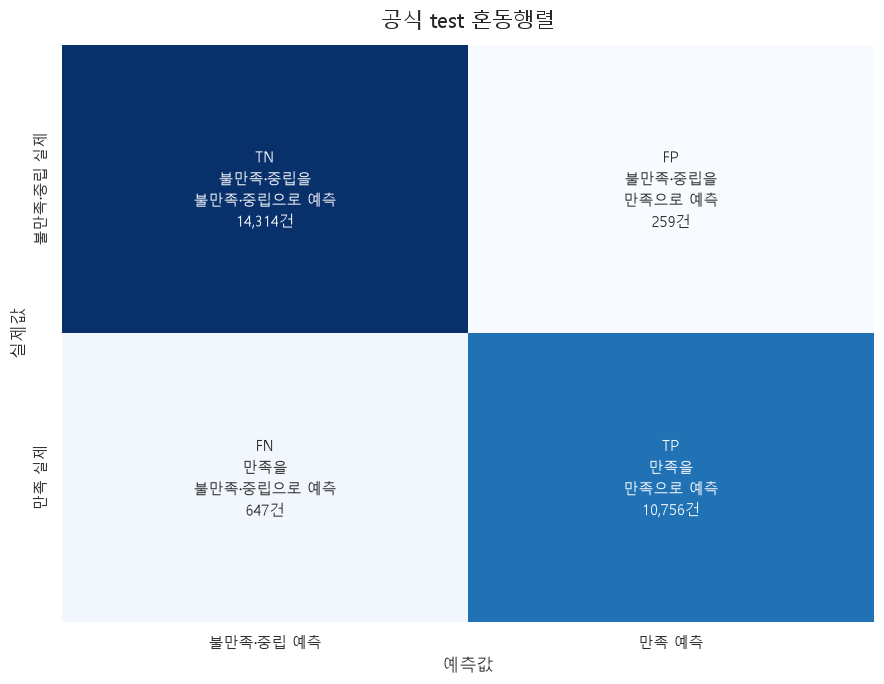

In [39]:
TN, FP, FN, TP = final_cm.ravel()

cm_labels = np.array([
    [
        f"TN\n불만족·중립을\n불만족·중립으로 예측\n{TN:,}건",
        f"FP\n불만족·중립을\n만족으로 예측\n{FP:,}건"
    ],
    [
        f"FN\n만족을\n불만족·중립으로 예측\n{FN:,}건",
        f"TP\n만족을\n만족으로 예측\n{TP:,}건"
    ]
])

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    final_cm,
    annot=cm_labels,
    fmt="",
    cmap="Blues",
    cbar=False,
    ax=ax,
    annot_kws={"fontsize": 11, "linespacing": 1.4},
    xticklabels=["불만족·중립 예측", "만족 예측"],
    yticklabels=["불만족·중립 실제", "만족 실제"]
)

ax.set_title("공식 test 혼동행렬", fontsize=15, pad=12)
ax.set_xlabel("예측값", fontsize=12)
ax.set_ylabel("실제값", fontsize=12)

plt.tight_layout()
plt.show()

## 11. 오분류 분석

In [26]:
error_analysis=X_test.copy()
error_analysis["실제값"]=y_test.to_numpy(); error_analysis["예측값"]=final_pred; error_analysis["만족 예측확률"]=final_proba
error_analysis["오분류 유형"]=np.select([
    (error_analysis["실제값"]==0)&(error_analysis["예측값"]==1),
    (error_analysis["실제값"]==1)&(error_analysis["예측값"]==0)
],["FP: 불만족을 만족으로 예측","FN: 만족을 불만족으로 예측"],default="정분류")
error_counts=error_analysis["오분류 유형"].value_counts().rename_axis("유형").reset_index(name="승객 수")
display(error_counts.style.hide(axis="index"))

error_service_profile=error_analysis[error_analysis["오분류 유형"]!="정분류"].groupby("오분류 유형")[service_cols].mean().T
display(error_service_profile.round(2))

유형,승객 수
정분류,25070
FN: 만족을 불만족으로 예측,647
FP: 불만족을 만족으로 예측,259


오분류 유형,FN: 만족을 불만족으로 예측,FP: 불만족을 만족으로 예측
Inflight wifi service,3.70,3.90
Departure/Arrival time convenient,3.28,3.26
Ease of Online booking,3.49,3.68
Gate location,2.88,3.12
Food and drink,3.08,3.51
Online boarding,3.54,3.74
Seat comfort,3.11,3.38
Inflight entertainment,3.07,3.56
On-board service,3.15,3.53
Leg room service,3.22,3.61


## 12. 전체 공식 train으로 재학습한 최종 모델의 Feature Importance와 SHAP

Feature Importance는 모델이 변수를 분할에 얼마나 활용했는지를, SHAP은 각 값이 만족·불만족 예측 방향에 기여한 정도를 보여준다. **Feature Importance와 SHAP은 모델 예측에 대한 기여도를 나타내며 실제 인과관계를 의미하지 않는다.**

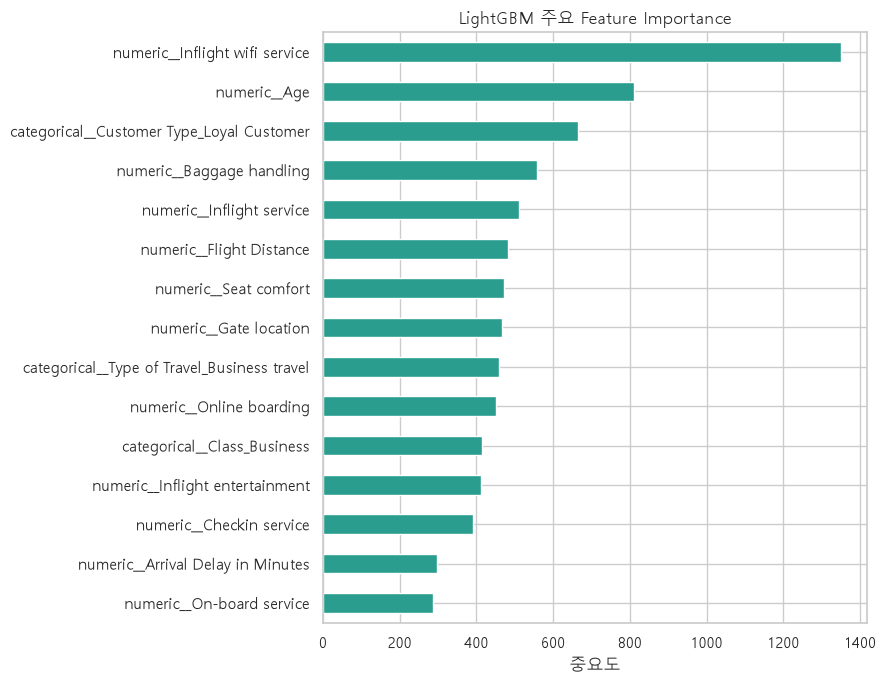

,중요도
numeric__Inflight wifi service,1351
numeric__Age,812
categorical__Customer Type_Loyal Customer,664
numeric__Baggage handling,559
numeric__Inflight service,512
numeric__Flight Distance,483
numeric__Seat comfort,473
numeric__Gate location,467
categorical__Type of Travel_Business travel,458
numeric__Online boarding,451


In [27]:
preprocessor_fitted = (
    final_model
    .named_steps["preprocessor"]
)

model_fitted = (
    final_model
    .named_steps["model"]
)
feature_names=preprocessor_fitted.get_feature_names_out()
importance=pd.Series(model_fitted.feature_importances_,index=feature_names).sort_values(ascending=False).head(15).sort_values()
importance.plot(kind="barh",figsize=(9,7),color="#2A9D8F")
plt.title(f"{selected_name} 주요 Feature Importance"); plt.xlabel("중요도"); plt.tight_layout(); plt.show()
display(importance.sort_values(ascending=False).to_frame("중요도").round(4))

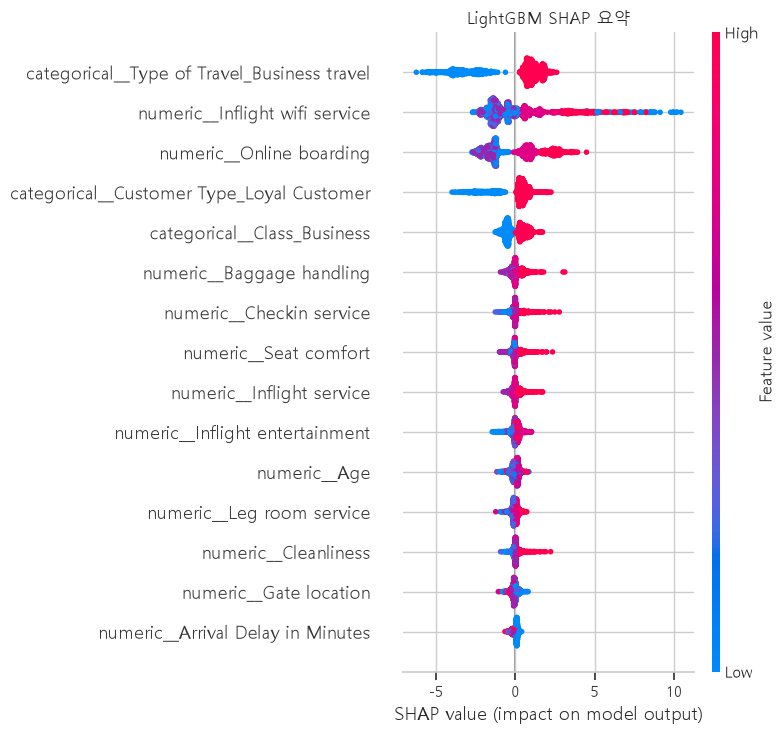

,평균 |SHAP|
categorical__Type of Travel_Business travel,1.7563
numeric__Inflight wifi service,1.5897
numeric__Online boarding,1.5163
categorical__Customer Type_Loyal Customer,0.7760
categorical__Class_Business,0.5384
numeric__Baggage handling,0.2617
numeric__Checkin service,0.2294
numeric__Seat comfort,0.1968
numeric__Inflight service,0.1865
numeric__Inflight entertainment,0.1800


변수,낮은 값(0~2) 평균 SHAP,높은 값(4~5) 평균 SHAP,해석
Inflight wifi service,-0.666100,2.108100,높은 값이 만족 예측을 높이는 방향
Online boarding,-1.555100,1.420100,높은 값이 만족 예측을 높이는 방향


**방향 해석:** 공식 train에서 추출한 2,000개 표본을 이용해 전체 train으로 재학습한 최종 LightGBM의 SHAP 값을 확인했다. Wi-Fi와 온라인 탑승수속의 높은 점수는 낮은 점수보다 만족 예측을 높이는 방향으로 나타났다. 이는 최종 모델의 예측 기여 방향이며, 해당 서비스를 변경했을 때 만족도가 상승한다는 인과효과를 증명하지 않는다.

In [28]:
X_shap = X.sample(
    n=min(
        2000,
        len(X)
    ),
    random_state=RANDOM_STATE
)

X_shap_transformed=preprocessor_fitted.transform(X_shap)
if hasattr(X_shap_transformed,"toarray"): X_shap_transformed=X_shap_transformed.toarray()
explainer=shap.TreeExplainer(model_fitted)
shap_values=explainer(X_shap_transformed)
shap.summary_plot(shap_values.values,X_shap_transformed,feature_names=feature_names,max_display=15,show=False)
plt.title(f"{selected_name} SHAP 요약"); plt.tight_layout(); plt.show()

mean_abs_shap=pd.Series(np.abs(shap_values.values).mean(axis=0),index=feature_names).sort_values(ascending=False).head(10)
display(mean_abs_shap.to_frame("평균 |SHAP|").round(4))

direction_rows = []
for feature in ["Inflight wifi service", "Online boarding"]:
    transformed_name = f"numeric__{feature}"
    feature_idx = list(feature_names).index(transformed_name)
    low_mask = X_shap[feature].le(2).to_numpy()
    high_mask = X_shap[feature].ge(4).to_numpy()
    direction_rows.append({
        "변수": feature,
        "낮은 값(0~2) 평균 SHAP": shap_values.values[low_mask, feature_idx].mean(),
        "높은 값(4~5) 평균 SHAP": shap_values.values[high_mask, feature_idx].mean(),
        "해석": "높은 값이 만족 예측을 높이는 방향" if shap_values.values[high_mask, feature_idx].mean() > shap_values.values[low_mask, feature_idx].mean() else "방향이 단순하지 않음"
    })
shap_direction_df = pd.DataFrame(direction_rows)
display(shap_direction_df.round(4).style.hide(axis="index"))
display(
    Markdown(
        "**방향 해석:** 공식 train에서 추출한 2,000개 표본을 이용해 "
        "전체 train으로 재학습한 최종 LightGBM의 SHAP 값을 확인했다. "
        "Wi-Fi와 온라인 탑승수속의 높은 점수는 낮은 점수보다 "
        "만족 예측을 높이는 방향으로 나타났다. "
        "이는 최종 모델의 예측 기여 방향이며, 해당 서비스를 변경했을 때 "
        "만족도가 상승한다는 인과효과를 증명하지 않는다."
    )
)

## 13. K-means 군집 분석

만족도 타깃은 군집 생성에서 제외한다. K-means는 거리 기반이므로 중앙값 대체 후 표준화하며, k=2~6을 실루엣뿐 아니라 Inertia·Calinski-Harabasz·Davies-Bouldin·최소 군집 비율로 함께 비교한다.

In [29]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score,calinski_harabasz_score,davies_bouldin_score

cluster_cols=["Age","Flight Distance","Departure Delay in Minutes","Arrival Delay in Minutes",
              "Inflight wifi service","Online boarding","Seat comfort","Inflight entertainment",
              "On-board service","Leg room service","Baggage handling","Checkin service","Inflight service","Cleanliness"]
X_cluster=train[cluster_cols].copy()
cluster_medians=X_cluster.median(numeric_only=True)
X_cluster=X_cluster.fillna(cluster_medians)
cluster_scaler=StandardScaler()
X_cluster_scaled=cluster_scaler.fit_transform(X_cluster)
assert not np.isnan(X_cluster_scaled).any()
print("군집 입력:",X_cluster.shape,"타깃 포함:",TARGET in cluster_cols)

군집 입력: (103904, 14) 타깃 포함: False


k,Inertia,Silhouette,Calinski-Harabasz,Davies-Bouldin,최소 군집 비율,군집별 승객 수
2,1199911.931900,0.175600,22058.686100,2.050200,0.473700,"{0: 49219, 1: 54685}"
3,1091198.685000,0.162100,17303.767300,2.093700,0.280100,"{0: 45009, 1: 29101, 2: 29794}"
4,978970.303500,0.171300,16828.481900,1.788300,0.036300,"{0: 27581, 1: 43604, 2: 3774, 3: 28945}"
5,923218.024400,0.145200,14952.053200,1.912800,0.034700,"{0: 25004, 1: 17287, 2: 34454, 3: 23558, 4: 3601}"
6,882843.118000,0.137000,13458.875000,1.959900,0.033800,"{0: 19932, 1: 30787, 2: 13697, 3: 15616, 4: 3511, 5: 20361}"


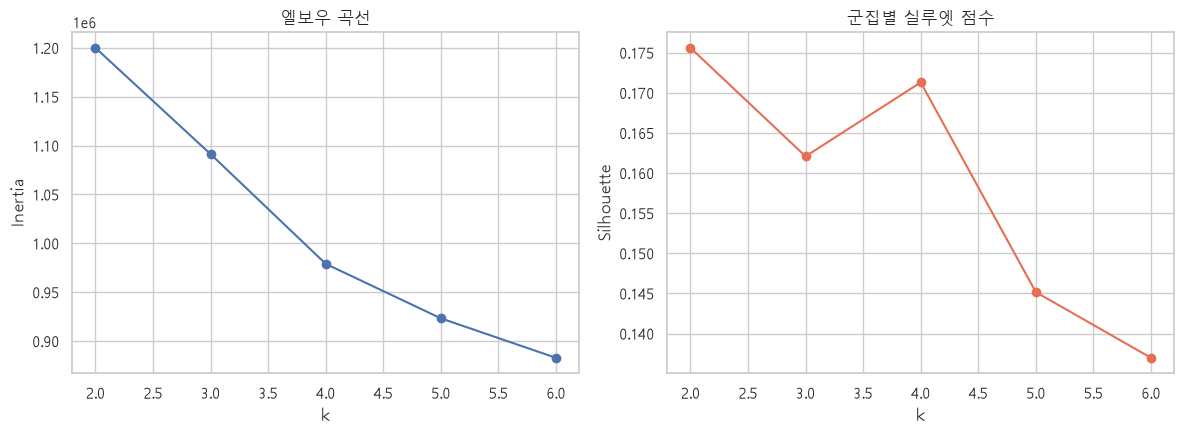

In [30]:
cluster_quality=[]; cluster_models={}; cluster_labels_by_k={}
for k in range(2,7):
    km=KMeans(n_clusters=k,random_state=RANDOM_STATE,n_init=10)
    labels=km.fit_predict(X_cluster_scaled)
    counts=pd.Series(labels).value_counts()
    cluster_quality.append({"k":k,"Inertia":km.inertia_,"Silhouette":silhouette_score(X_cluster_scaled,labels,sample_size=10000,random_state=RANDOM_STATE),
                            "Calinski-Harabasz":calinski_harabasz_score(X_cluster_scaled,labels),"Davies-Bouldin":davies_bouldin_score(X_cluster_scaled,labels),
                            "최소 군집 비율":counts.min()/len(labels),"군집별 승객 수":str(counts.sort_index().to_dict())})
    cluster_models[k]=km; cluster_labels_by_k[k]=labels
cluster_quality_df=pd.DataFrame(cluster_quality)
display(cluster_quality_df.round(4).style.hide(axis="index"))

fig,axes=plt.subplots(1,2,figsize=(12,4.5))
axes[0].plot(cluster_quality_df["k"],cluster_quality_df["Inertia"],marker="o"); axes[0].set(title="엘보우 곡선",xlabel="k",ylabel="Inertia")
axes[1].plot(cluster_quality_df["k"],cluster_quality_df["Silhouette"],marker="o",color="#E76F51"); axes[1].set(title="군집별 실루엣 점수",xlabel="k",ylabel="Silhouette")
plt.tight_layout(); plt.show()

### 지연시간 `log1p` 적용 민감도 분석

분류 모델에는 원본 지연시간을 유지했지만, K-means는 거리 기반이므로 극단적으로 긴 지연이 군집 거리를 주도할 수 있다. 따라서 군집에서만 지연시간에 `log1p`를 적용한 대안과 raw 입력을 같은 k=2~6 조건으로 비교한다. 결과가 뚜렷하게 개선되지 않으면 원본 구성을 유지한다.

In [31]:
delay_cols = ["Departure Delay in Minutes", "Arrival Delay in Minutes"]
X_cluster_log = X_cluster.copy()
X_cluster_log[delay_cols] = np.log1p(X_cluster_log[delay_cols])
X_cluster_log_scaled = StandardScaler().fit_transform(X_cluster_log)

log_quality = []
for k in range(2, 7):
    km_log = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_log = km_log.fit_predict(X_cluster_log_scaled)
    log_quality.append({
        "k": k,
        "log1p Silhouette": silhouette_score(
            X_cluster_log_scaled, labels_log,
            sample_size=10000, random_state=RANDOM_STATE
        ),
        "log1p Davies-Bouldin": davies_bouldin_score(X_cluster_log_scaled, labels_log)
    })

cluster_transform_comparison = cluster_quality_df[["k", "Silhouette", "Davies-Bouldin"]].merge(
    pd.DataFrame(log_quality), on="k"
).rename(columns={
    "Silhouette": "raw Silhouette",
    "Davies-Bouldin": "raw Davies-Bouldin"
})
display(cluster_transform_comparison.round(4).style.hide(axis="index"))

raw_k4 = cluster_transform_comparison.loc[cluster_transform_comparison["k"] == 4, "raw Silhouette"].iloc[0]
log_k4 = cluster_transform_comparison.loc[cluster_transform_comparison["k"] == 4, "log1p Silhouette"].iloc[0]
display(Markdown(
    f"**해석:** k=4의 Silhouette는 raw {raw_k4:.4f}, log1p {log_k4:.4f}이다. "
    "변환 결과가 군집 품질을 명확히 개선할 때만 대안을 채택하며, 그렇지 않으면 해석 일관성을 위해 raw 입력을 유지한다."
))

k,raw Silhouette,raw Davies-Bouldin,log1p Silhouette,log1p Davies-Bouldin
2,0.175600,2.050200,0.166200,2.117800
3,0.162100,2.093700,0.151800,2.168200
4,0.171300,1.788300,0.144000,2.016500
5,0.145200,1.912800,0.127200,2.073100
6,0.137000,1.959900,0.126700,2.057500


**해석:** k=4의 Silhouette는 raw 0.1713, log1p 0.1440이다. 변환 결과가 군집 품질을 명확히 개선할 때만 대안을 채택하며, 그렇지 않으면 해석 일관성을 위해 raw 입력을 유지한다.

### 군집 수 선택 기준

군집 품질만 평가하면 k=2의 실루엣 점수가 가장 높았다.
따라서 수치적으로 최적인 군집 수를 k=4라고 단정할 수 없다.

다만 k=2는 승객을 크게 두 집단으로만 구분하여 서비스 개선 대상을
세부적으로 설명하기 어려웠다. 본 프로젝트에서는 군집 품질과
프로파일 해석 가능성을 함께 고려하여 k=4를 탐색적 세분화 결과로
추가 분석했다.

k=4의 실루엣 점수는 약 0.17이고 최소 군집 비율은 약 3.6%이다.
따라서 군집 간 분리가 강하거나 확정적인 자연 고객군이라고
해석하지 않는다.

- **k=2:** 수치적 군집 품질 기준
- **k=4:** 서비스 개선 유형을 위한 탐색적 세분화

In [32]:
FINAL_K=4
final_kmeans=cluster_models[FINAL_K]
cluster_labels=cluster_labels_by_k[FINAL_K]
cluster_result=train.copy()
cluster_result["군집"]=cluster_labels

stability=[]
for seed in [10,20,30,40,50]:
    km=KMeans(n_clusters=FINAL_K,random_state=seed,n_init=10)
    labels=km.fit_predict(X_cluster_scaled)
    stability.append({"초기값":seed,"Silhouette":silhouette_score(X_cluster_scaled,labels,sample_size=10000,random_state=RANDOM_STATE),"Inertia":km.inertia_})
stability_df=pd.DataFrame(stability)
display(stability_df.round(4).style.hide(axis="index"))

초기값,Silhouette,Inertia
10,0.171300,978970.303500
20,0.171300,978970.350000
30,0.171300,978970.472300
40,0.171300,978970.492900
50,0.171300,978970.417400


## 14. PCA 시각화와 군집 프로파일

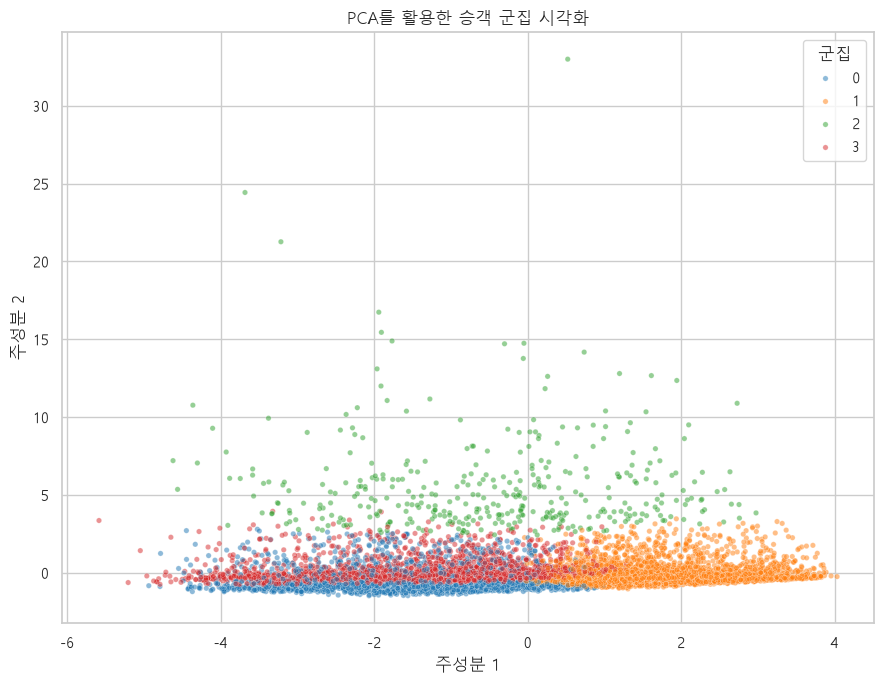

두 주성분 설명분산 비율 합: 0.3895


PCA는 시각화에만 사용했으며 K-means는 표준화된 원래 14차원 공간에서 학습했다.

In [33]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2,random_state=RANDOM_STATE)
pca_values=pca.fit_transform(X_cluster_scaled)
pca_df=pd.DataFrame({"주성분 1":pca_values[:,0],"주성분 2":pca_values[:,1],"군집":cluster_labels})
pca_sample=pca_df.sample(n=10000,random_state=RANDOM_STATE)
plt.figure(figsize=(9,7)); sns.scatterplot(data=pca_sample,x="주성분 1",y="주성분 2",hue="군집",palette="tab10",s=15,alpha=.5)
plt.title("PCA를 활용한 승객 군집 시각화"); plt.tight_layout(); plt.show()
print("두 주성분 설명분산 비율 합:",round(pca.explained_variance_ratio_.sum(),4))
display(Markdown("PCA는 시각화에만 사용했으며 K-means는 표준화된 원래 14차원 공간에서 학습했다."))

In [34]:
cluster_result["만족 여부"]=cluster_result[TARGET].map(target_map)
profile=cluster_result.groupby("군집").agg(
    승객_수=(TARGET,"size"), 
    만족도_비율=("만족 여부","mean"),
    충성고객_비율=("Customer Type",lambda s:(s=="Loyal Customer").mean()),
    업무여행_비율=("Type of Travel",lambda s:(s=="Business travel").mean()),
    비즈니스석_비율=("Class",lambda s:(s=="Business").mean()),
    나이_평균=("Age","mean"), 
    비행거리_평균=("Flight Distance","mean"),
    출발지연_평균=("Departure Delay in Minutes","mean"),
    출발지연_중앙값=("Departure Delay in Minutes","median"),
    도착지연_평균=("Arrival Delay in Minutes","mean"),
    도착지연_중앙값=("Arrival Delay in Minutes","median")
)
service_profile=cluster_result.groupby("군집")[service_cols].mean()
display(profile.round(4))
display(service_profile.round(2).T)

cluster_names={}
for k in profile.index:
    if service_profile.loc[k].mean()==service_profile.mean(axis=1).max(): name="전반적 서비스 고평가형"
    elif cluster_result.loc[cluster_result["군집"]==k,"Arrival Delay in Minutes"].mean()==cluster_result.groupby("군집")["Arrival Delay in Minutes"].mean().max(): name="지연 경험 집중형"
    elif service_profile.loc[k,["Seat comfort","Inflight entertainment","Cleanliness"]].mean()<service_profile[["Seat comfort","Inflight entertainment","Cleanliness"]].mean(axis=1).median(): name="객실환경 저평가형"
    else: name="운영서비스 개선형"
    cluster_names[k]=name
profile_named=profile.reset_index(); profile_named["군집 유형"]=profile_named["군집"].map(cluster_names)
display(profile_named.round(4).style.hide(axis="index"))
display(Markdown("군집 이름은 원본 평균 프로파일을 근거로 붙였다. 군집 번호 자체에는 의미가 없으며 초기값이나 데이터가 바뀌면 번호가 달라질 수 있다."))

,승객_수,만족도_비율,충성고객_비율,업무여행_비율,비즈니스석_비율,나이_평균,비행거리_평균,출발지연_평균,출발지연_중앙값,도착지연_평균,도착지연_중앙값
군집,,,,,,,,,,,
0,27581,0.1737,0.6817,0.5665,0.2732,31.8796,859.6665,9.8113,0.0,10.2903,0.0
1,43604,0.7092,0.8829,0.7805,0.6749,42.0332,1451.4432,8.4458,0.0,8.4796,0.0
2,3774,0.3524,0.8031,0.6993,0.4438,38.6571,1165.8127,165.3434,140.0,168.0298,143.0
3,28945,0.2757,0.8496,0.6688,0.3809,42.6233,1112.0911,9.5533,0.0,9.9926,0.0


군집,0,1,2,3
Inflight wifi service,2.33,3.08,2.70,2.59
Departure/Arrival time convenient,3.03,3.17,3.06,2.91
Ease of Online booking,2.47,2.98,2.73,2.69
Gate location,2.96,2.99,3.02,2.97
Food and drink,2.04,3.77,3.08,3.47
Online boarding,2.23,3.87,3.18,3.30
Seat comfort,1.98,4.21,3.32,3.69
Inflight entertainment,2.12,4.39,3.29,3.00
On-board service,3.30,4.19,3.23,2.27
Leg room service,3.28,3.97,3.51,2.47


군집,승객_수,만족도_비율,충성고객_비율,업무여행_비율,비즈니스석_비율,나이_평균,비행거리_평균,출발지연_평균,출발지연_중앙값,도착지연_평균,도착지연_중앙값,군집 유형
0,27581,0.173700,0.681700,0.566500,0.273200,31.879600,859.666500,9.811300,0.000000,10.290300,0.000000,객실환경 저평가형
1,43604,0.709200,0.882900,0.780500,0.674900,42.033200,1451.443200,8.445800,0.000000,8.479600,0.000000,전반적 서비스 고평가형
2,3774,0.352400,0.803100,0.699300,0.443800,38.657100,1165.812700,165.343400,140.000000,168.029800,143.000000,지연 경험 집중형
3,28945,0.275700,0.849600,0.668800,0.380900,42.623300,1112.091100,9.553300,0.000000,9.992600,0.000000,운영서비스 개선형


군집 이름은 원본 평균 프로파일을 근거로 붙였다. 군집 번호 자체에는 의미가 없으며 초기값이나 데이터가 바뀌면 번호가 달라질 수 있다.

## 15. 자동 품질 검사

In [35]:
import json
quality_checks={
    "타깃이 X에 없음": TARGET not in X.columns,
    "ID 컬럼 제거": set(ID_COLS).isdisjoint(X.columns),
    "train/validation/test 컬럼 일치": X_train.columns.equals(X_valid.columns) and X_train.columns.equals(X_test.columns),
    "군집 결측치 없음": int(np.isnan(X_cluster_scaled).sum())==0,
    "모든 주요 random_state=10": RANDOM_STATE==10 and cv.random_state==10,
    "공식 임계값 0.50": FINAL_THRESHOLD==0.50,
    "test 예측 길이 일치": len(final_pred)==len(y_test),
    "실험 로그 존재": len(experiment_log)>=7,
    "SHAP 표본 제한": len(X_shap)<=2000,
    "범주형 카디널리티 확인": len(categorical_cardinality)==len(categorical_cols_eda),
    "군집 raw-log1p 비교": set(cluster_transform_comparison["k"])==set(range(2,7)),
    "서비스 척도 확인": service_scale_check["결측 수"].sum()==0,
    "상관관계 상위 쌍 확인": len(top_corr_pairs)==10,
    "SHAP 방향성 표 존재": len(shap_direction_df)==2
}
quality_df=pd.DataFrame({"검사항목":quality_checks.keys(),"통과":quality_checks.values()})
display(quality_df.style.hide(axis="index"))
assert all(quality_checks.values())
print("자동 품질 검사: 모두 통과")

검사항목,통과
타깃이 X에 없음,True
ID 컬럼 제거,True
train/validation/test 컬럼 일치,True
군집 결측치 없음,True
모든 주요 random_state=10,True
공식 임계값 0.50,True
test 예측 길이 일치,True
실험 로그 존재,True
SHAP 표본 제한,True
범주형 카디널리티 확인,True


자동 품질 검사: 모두 통과


## 16. 실제 실행 결과 기반 종합 결론

In [36]:
best_cluster_quality=cluster_quality_df.loc[cluster_quality_df["k"]==FINAL_K].iloc[0]
top_features=mean_abs_shap.head(5).index.str.replace("numeric__","",regex=False).str.replace("categorical__","",regex=False).tolist()
display(Markdown(f"""
### 발표용 최종 요약

1. 동일한 Stratified 5-Fold에서 5개 분류 모델을 비교하고 성능·과적합을 고려한 boosting 후보 두 종을 제한 GridSearchCV로 튜닝한 결과, **{selected_name}**을 선택했다. 최적 파라미터는 `{selected_params}`이다.
2. 공식 test를 마지막 한 번 평가한 결과 **Accuracy {final_metrics['Accuracy']:.4f}, F1 {final_metrics['F1-score']:.4f}, ROC-AUC {final_metrics['ROC-AUC']:.4f}**였다. 혼동행렬은 TN {tn:,}, FP {fp:,}, FN {fn:,}, TP {tp:,}이다.
3. SHAP 기준 주요 예측 변수에는 **{', '.join(top_features)}**가 포함되었다. 이는 모델 예측 기여이며 인과관계가 아니다.
4. 임계값 0.50을 공식 결과로 사용했다. 0.75는 FP를 줄이는 대신 Recall과 F1이 낮아지는 운영 시나리오로만 제시한다.
5. k=2는 수치적 군집 품질 기준이며, k=4는 서비스 개선 유형을 세분화하기 위한 탐색적 선택이다. k=4 군집의 Silhouette는 {best_cluster_quality['Silhouette']:.4f}, Calinski-Harabasz는 {best_cluster_quality['Calinski-Harabasz']:.1f}, Davies-Bouldin은 {best_cluster_quality['Davies-Bouldin']:.4f}, 최소 군집 비율은 {best_cluster_quality['최소 군집 비율']:.4f}였다. 분리도가 강하지 않아 탐색적 승객 세분화로 해석한다.

### 항공 서비스 실행 제안

- 전체 승객 공통으로 기내 Wi-Fi와 온라인 탑승수속의 품질 및 장애 대응을 우선 점검한다.
- 객실환경 저평가형에는 좌석 편안함·청결·기내 엔터테인먼트 개선을 우선한다.
- 운영서비스 개선형에는 탑승 서비스·수하물 처리·기내 서비스의 접점 품질을 우선한다.
- 지연 경험 집중형에는 지연 자체뿐 아니라 사전 안내·대체편·보상 프로세스를 함께 검토한다.
- 군집별 제안은 탐색적 가설이며 실제 정책 적용 전 A/B 테스트나 후속 기간 데이터로 검증한다.

### 한계와 향후 개선

- 설문 평점만으로 구체적인 불만 사유와 실제 인과효과를 확인할 수 없다.
- 항공사·노선·항공권 가격·예약 시점·운항 상황 등의 추가 데이터가 필요하다.
- FP와 FN의 실제 비용자료가 없어 운영 임계값은 현업 비용을 반영해 다시 결정해야 한다.
- k=4의 최소 군집 비율이 작고 실루엣도 약 0.17이므로 명확한 자연 집단으로 일반화할 수 없다. 지연시간 log1p 민감도 분석도 함께 확인했으며, 향후 다른 변수 구성과 군집 알고리즘을 비교할 필요가 있다.
"""))


### 발표용 최종 요약

1. 동일한 Stratified 5-Fold에서 5개 분류 모델을 비교하고 성능·과적합을 고려한 boosting 후보 두 종을 제한 GridSearchCV로 튜닝한 결과, **LightGBM**을 선택했다. 최적 파라미터는 `{'model__learning_rate': 0.05, 'model__max_depth': -1, 'model__n_estimators': 150, 'model__num_leaves': 63}`이다.
2. 공식 test를 마지막 한 번 평가한 결과 **Accuracy 0.9651, F1 0.9596, ROC-AUC 0.9955**였다. 혼동행렬은 TN 14,314, FP 259, FN 647, TP 10,756이다.
3. SHAP 기준 주요 예측 변수에는 **Type of Travel_Business travel, Inflight wifi service, Online boarding, Customer Type_Loyal Customer, Class_Business**가 포함되었다. 이는 모델 예측 기여이며 인과관계가 아니다.
4. 임계값 0.50을 공식 결과로 사용했다. 0.75는 FP를 줄이는 대신 Recall과 F1이 낮아지는 운영 시나리오로만 제시한다.
5. k=2는 수치적 군집 품질 기준이며, k=4는 서비스 개선 유형을 세분화하기 위한 탐색적 선택이다. k=4 군집의 Silhouette는 0.1713, Calinski-Harabasz는 16828.5, Davies-Bouldin은 1.7883, 최소 군집 비율은 0.0363였다. 분리도가 강하지 않아 탐색적 승객 세분화로 해석한다.

### 항공 서비스 실행 제안

- 전체 승객 공통으로 기내 Wi-Fi와 온라인 탑승수속의 품질 및 장애 대응을 우선 점검한다.
- 객실환경 저평가형에는 좌석 편안함·청결·기내 엔터테인먼트 개선을 우선한다.
- 운영서비스 개선형에는 탑승 서비스·수하물 처리·기내 서비스의 접점 품질을 우선한다.
- 지연 경험 집중형에는 지연 자체뿐 아니라 사전 안내·대체편·보상 프로세스를 함께 검토한다.
- 군집별 제안은 탐색적 가설이며 실제 정책 적용 전 A/B 테스트나 후속 기간 데이터로 검증한다.

### 한계와 향후 개선

- 설문 평점만으로 구체적인 불만 사유와 실제 인과효과를 확인할 수 없다.
- 항공사·노선·항공권 가격·예약 시점·운항 상황 등의 추가 데이터가 필요하다.
- FP와 FN의 실제 비용자료가 없어 운영 임계값은 현업 비용을 반영해 다시 결정해야 한다.
- k=4의 최소 군집 비율이 작고 실루엣도 약 0.17이므로 명확한 자연 집단으로 일반화할 수 없다. 지연시간 log1p 민감도 분석도 함께 확인했으며, 향후 다른 변수 구성과 군집 알고리즘을 비교할 필요가 있다.
